## 03. Rolling Average and Structural Regime Analysis

In [0]:
%pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.8 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import ruptures as rpt
from statsmodels.tsa.seasonal import seasonal_decompose

We focus on Canada Total to analyze national-level structural trends rather than regional fluctuations.

In [0]:
BASE_PATH = "/Workspace/Users/kimjylin@gmail.com/ca_gas_supply_trends"

df = pd.read_csv(
    f"{BASE_PATH}/data/processed/canadian_marketable_gas_2000_25_103m3d.csv"
)

# Keep Canada Total only
df = df[df["Province"] == "Canada Total"].copy()

# Ensure Month column is numeric (1-12)
if df["Month"].dtype == object:
    df["Month"] = pd.to_datetime(df["Month"], format='%B').dt.month

# Create a datetime column for potential monthly plots
df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Year,Month,Province,Production_e3m3d,Date
0,2000,1,Canada Total,463099.0,2000-01-01
1,2000,2,Canada Total,470450.0,2000-02-01
2,2000,3,Canada Total,474403.0,2000-03-01
3,2000,4,Canada Total,481287.0,2000-04-01
4,2000,5,Canada Total,472605.0,2000-05-01


### Rolling average (3-year)

To smooth out annual fluctuations (noise) and highlight long-term structural trends, we apply a 3-year rolling windows.

With this setup, each data point is calculated as the average of the previous, current, and following years.

In [0]:
# Aggregate to annual
annual_df = df.groupby("Year")["Production_e3m3d"].mean().reset_index()

annual_df["Production_roll3"] = annual_df["Production_e3m3d"].rolling(window=3, center=True).mean()

annual_df.head()

,Year,Production_e3m3d,Production_roll3
0,2000,473329.500000,NaN
1,2001,494688.250000,486165.472222
2,2002,490478.666667,486233.833333
3,2003,473534.583333,481235.555556
4,2004,479693.416667,478392.583333


### Calculate YoY Growth (Annual Percentage Change)

Used to determine whether there is an annual growth or decline trend.

In [0]:
annual_df["YoY_pct"] = annual_df["Production_e3m3d"].pct_change() * 100

In [0]:
valid_df = annual_df.dropna(subset=["Production_roll3"])

series = valid_df["Production_roll3"].values
years = valid_df["Year"].values

# PELT algorithm for change-point detection
algo = rpt.Pelt(model="rbf").fit(series)

# The pen controls sensitivity; the smaller the pen, the easier it is to detect changes.
breakpoints = algo.predict(pen=1)

# Remove last breakpoint if it's just the end of series
if breakpoints[-1] == len(years):
    breakpoints = breakpoints[:-1]

# Corresponding year (excluding the last break, as it is the end)
change_years = [years[bp-1] for bp in breakpoints if bp > 0]
print("Detected structural change years:", change_years)

Detected structural change years: [np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020)]


In [0]:
# Regime classification
def classify_regime(x):
    if x > 3:
        return "High Growth"
    elif x < -3:
        return "Decline"
    else:
        return "Plateau / Volatile"

annual_df["Regime"] = annual_df["YoY_pct"].apply(classify_regime)

# Count of each regime
print(annual_df["Regime"].value_counts())

Regime
Plateau / Volatile    15
High Growth            6
Decline                5
Name: count, dtype: int64


Preliminary EDA (Yearly YoY Growth)

- This directly looks at the percentage increase or decrease in output each year, without smoothing.
- Results: 12 years showed rapid growth, 8 years of decline, and 5 years of relative stability.
- Interpretation: This method is very "sensitive," capturing short-term fluctuations and large single-year increases or decreases → suitable for observing specific annual performance.

Rolling Average & Structural Regime Analysis
- Here, we first perform a 3-year rolling average on the data, then categorize it according to YoY changes.
- Results: High-growth years decreased from 12 to 6, declining years decreased from 8 to 5, and stable/plateau years increased to 15.
- Interpretation: The rolling average "smooths out" short-term fluctuations, retaining only long-term trends and structural changes.
  - Small increases or decreases in a single year are no longer considered "high growth/decline."
  - This reflects the true long-term growth or stagnation period.

EDA shows short-term ups and downs (“sensitive” view), while Rolling Average and Structural Regime Analysis highlights long-term structural regimes (“smoothed” and more conservative view)

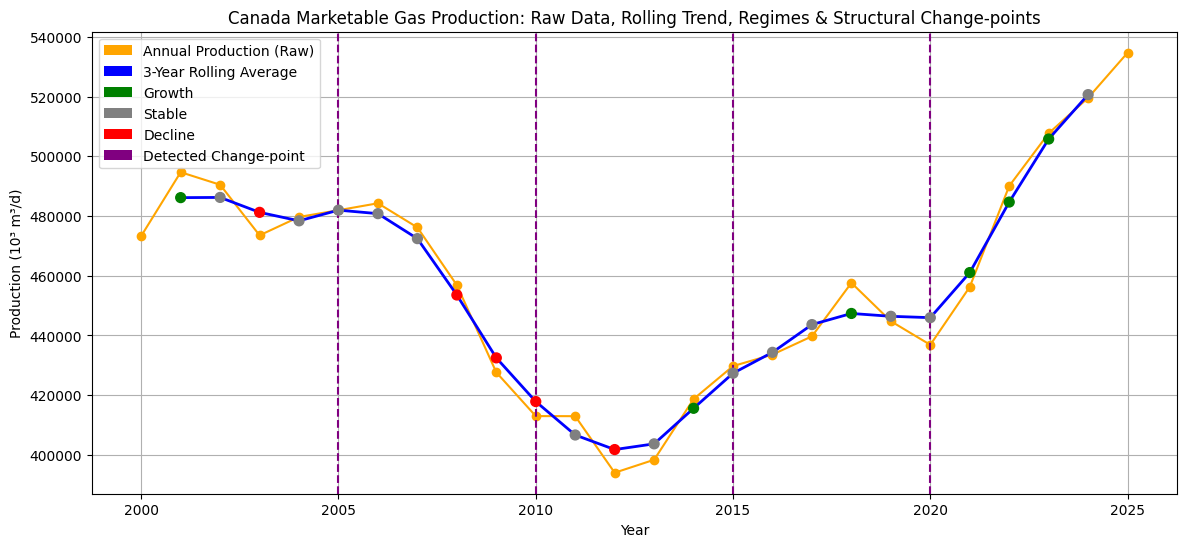

In [0]:
plt.figure(figsize=(14,6))

# Original annual production (YoY fluctuations)
plt.plot(
    annual_df["Year"],
    annual_df["Production_e3m3d"],
    marker='o',
    linestyle='-',
    color="orange",
    label="Annual Production (Raw)"
)

# 3-year Rolling Smoothed Data
plt.plot(
    annual_df["Year"],
    annual_df["Production_roll3"],
    color="blue",
    linewidth=2,
    label="3-Year Rolling Avg"
)

# Regime color point
colors = annual_df["Regime"].map({
    "High Growth": "green",
    "Plateau / Volatile": "gray",
    "Decline": "red"
})
plt.scatter(
    annual_df["Year"],
    annual_df["Production_roll3"],
    color=colors,
    s=50,
    zorder=5,
    label="Regime"
)

# 4. Change-points
for i, cy in enumerate(change_years):
    plt.axvline(
        cy,
        color="purple",
        linestyle="--",
        label="Detected Change-point" if i == 0 else None
    )

plt.title("Canada Marketable Gas Production: Raw Data, Rolling Trend, Regimes & Structural Change-points")
plt.xlabel("Year")
plt.ylabel("Production (10³ m³/d)")
plt.grid(True)

legend_elements = [
    Patch(facecolor="orange", label="Annual Production (Raw)"),
    Patch(facecolor="blue", label="3-Year Rolling Average"),
    Patch(facecolor="green", label="Growth"),
    Patch(facecolor="gray", label="Stable"),
    Patch(facecolor="red", label="Decline"),
    Patch(facecolor="purple", label="Detected Change-point")
]
plt.legend(handles=legend_elements, loc="upper left")

plt.show()


The detected change points line up with major shifts in the North American gas market.

Around 2005, production dynamics began to change as shale gas development started to influence supply growth.

By 2010, the U.S. shale gas boom had matured, increasing supply and putting pressure on prices, which altered Canada’s production growth pattern.

Around 2015, production shifted from growth to a more stable plateau following the 2014–2015 oil and gas price collapse.

In 2020, another structural change occurred, reflecting the impact of COVID-19 disruptions and subsequent market restructuring.